In [1]:
import torch#导入torch库
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
# 为什么导入了torch还要再导入里面的小库呢？
# 因为torch里包扩torch.utils.data，但是不不包括torch.utils.data里的dataloader
# 数据预处理
transform = transforms.ToTensor()#这是用在告诉下面的dataloader要把图片转成张量

# 下载数据
train_dataset = datasets.MNIST(#选择训练数据集
    root="./data",#根目录下面也一样
    train=True,#用于训练
    transform=transform,#转张量
    download=True#不是本地数据集，下载
)

test_dataset = datasets.MNIST(#选择测试数据集
    root="./data",#根目录
    train=False,#不用于训练
    transform=transform,#转张量
    download=True#不是本地数据集
)

# DataLoader
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True, num_workers=2)#导入训练数据集，batchsize（一次导入）1024张图，shuffle（打乱）✅，子进程4个
test_loader = DataLoader(test_dataset, batch_size=1024)#导入测试数据集，1024张图一次

100.0%
100.0%
100.0%
100.0%


In [2]:
import torch.nn as nn#导入nn功能


class CNNNet(nn.Module):#创建一个CNN-NET符合nn.Module的pytorch规则
    def __init__(self):#构造函数__init__,参数self
        super().__init__()#先把nn中的__init__函数搬过来，然后下面的东西你自己写

        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # 图片卷积，图片尺寸(1,28,28) → (16,28,28)
        self.relu = nn.ReLU()#定义激活函数
        self.pool = nn.MaxPool2d(2)#最大池化，边长尺寸为2
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)  #(16,28,28)->(32,28,28)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=11, padding=4)  #(32,28,28->64,28,28)
        self.fc = nn.Linear(64 * 13 * 13, 10)#线性层

    def forward(self, x):#定义了前向传播函数
        x = self.conv1(x)
        x = self.relu(x)
        x = self.conv2(x)
        x = self.relu(x)
        x = self.conv3(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x

In [3]:
model = CNNNet()#定义model为一个CNNNet对象（你上面定义的）

loss_fn = nn.CrossEntropyLoss()#创建一个交叉熵损失函数
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)#创建一个 Adam 优化器，用来更新模型参数，

In [4]:
device = torch.device("mps")#定义device为的苹果gpu加速后段
model.to(device)#将网络移植到设备上
losses = []#创建损失函数的结果列表
for epoch in range(20):#20轮
    print("epoch:", epoch)
    for images, labels in train_loader:#按batch读取数据
        images = images.to(device)  #图片移动到gpu
        labels = labels.to(device)  #标签移动到gpu
        outputs = model(images)#前向传播
        loss = loss_fn(outputs, labels)#计算loss
        print("epoch",epoch,"loss",loss.item())
        losses.append(loss.item())#记录loss
        optimizer.zero_grad()#梯度清零
        loss.backward()#反向传播
        optimizer.step()#更新参数

epoch: 0
epoch 0 loss 2.3054990768432617
epoch 0 loss 2.2492904663085938
epoch 0 loss 2.149242877960205
epoch 0 loss 1.9793248176574707
epoch 0 loss 1.658508062362671
epoch 0 loss 1.3266611099243164
epoch 0 loss 1.01862370967865
epoch 0 loss 0.9521286487579346
epoch 0 loss 0.9219611883163452
epoch 0 loss 0.6999278664588928
epoch 0 loss 0.7016720771789551
epoch 0 loss 0.5761102437973022
epoch 0 loss 0.5469021797180176
epoch 0 loss 0.4396660029888153
epoch 0 loss 0.43529894948005676
epoch 0 loss 0.5074352025985718
epoch 0 loss 0.3857942819595337
epoch 0 loss 0.405747652053833
epoch 0 loss 0.3798046112060547
epoch 0 loss 0.38705480098724365
epoch 0 loss 0.4034503400325775
epoch 0 loss 0.3675202429294586
epoch 0 loss 0.32939180731773376
epoch 0 loss 0.3863180875778198
epoch 0 loss 0.33069485425949097
epoch 0 loss 0.32320159673690796
epoch 0 loss 0.2935259938240051
epoch 0 loss 0.27443742752075195
epoch 0 loss 0.2788560688495636
epoch 0 loss 0.2495969533920288
epoch 0 loss 0.253135323524475

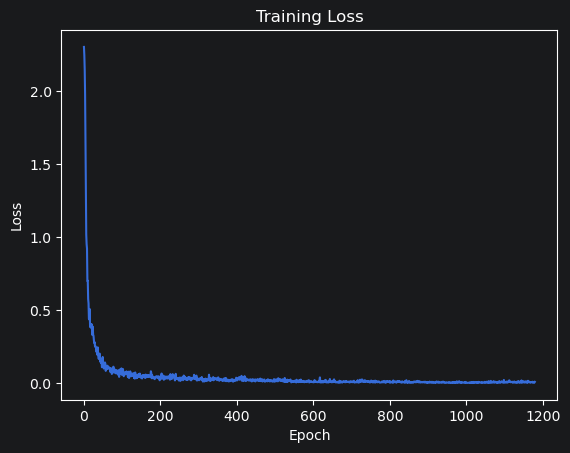

In [5]:
import matplotlib.pyplot as plt

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

In [6]:
correct = 0  # 正确数量

total = 0  # 总数量

model.eval()  # 切换测试模式

with torch.no_grad():  # 关闭梯度计算

    for images, labels in test_loader:  # 读取测试数据

        images = images.to(device)  # 图片移动到GPU
        labels = labels.to(device)  # 标签移动到GPU

        outputs = model(images)  # 前向传播

        _, predicted = torch.max(outputs, 1)  # 获取预测类别

        total += labels.size(0)  # 累加总数

        correct += (predicted == labels).sum().item()  # 累加正确数

print("accuracy:", correct / total)  # 输出准确率

accuracy: 0.9907
